# PoC Inferência - Classificação de Calçadas Curitiba (Project Sidewalk)
Este notebook realiza testes exploratórios do modelo do Project Sidewalk em amostras reais de Curitiba.

Copiamos os scripts básicos de arquitetura do repositório oficial (`sidewalk_models.py` e a pasta `dinov2`) diretamente para dentro de `scripts/` para que tudo rode de maneira independente.

In [3]:
import os
import sys
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import torchvision.transforms as T

sys.path.append(os.path.abspath('../scripts/utils'))

try:
    from sidewalk_models import DinoVisionTransformerClassifier, CLIP_Classifier
    print("Wrappers locais importados com sucesso!")
except ImportError as e:
    print(f"Erro ao importar os modelos locais: {e}")

Wrappers locais importados com sucesso!


/home/carlos/APx-2026.2-Task2-Producao-de-dados-de-qualidade-e-tipologia-de-calcadas/scripts/utils/dinov2/layers/swiglu_ffn.py:45: UserWarning: xFormers is disabled (SwiGLU)
  warnings.warn("xFormers is disabled (SwiGLU)")
/home/carlos/APx-2026.2-Task2-Producao-de-dados-de-qualidade-e-tipologia-de-calcadas/scripts/utils/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/carlos/APx-2026.2-Task2-Producao-de-dados-de-qualidade-e-tipologia-de-calcadas/scripts/utils/dinov2/layers/attention.py:29: UserWarning: xFormers is disabled (Attention)
  warnings.warn("xFormers is disabled (Attention)")
/home/carlos/APx-2026.2-Task2-Producao-de-dados-de-qualidade-e-tipologia-de-calcadas/scripts/utils/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/carlos/APx-2026.2-Task2-Producao-de-dados-de-qualidade-e-tipologia-de-ca

## 1. Configuração e Carregamento do Modelo

Aqui configuramos a arquitetura do modelo DINOv2 e as transformações de imagem exigidas por ele.

**ATENÇÃO:** Para o teste real funcionar, você precisa baixar o arquivo de pesos treinado (`.pth`) e colocá-lo na pasta `data/models/`. Atualize a variável `CAMINHO_PESOS` com o nome correto do arquivo.

In [2]:
# ==========================================
# 1. Configuração do Modelo
# ==========================================

CAMINHO_PESOS = '../data/models/dinov2_base_sidewalk.pth'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Transformações de imagem (DINOv2 exige múltiplos de 14 para o patch de atenção)
# 518x518 é um múltiplo de 14 próximo do usado no treinamento original
transform = T.Compose([
    T.Resize((518, 518)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def carregar_modelo_real(caminho_pesos, device=DEVICE):
    if os.path.exists(caminho_pesos):
        print(f"Carregando pesos de {caminho_pesos}...")
        model_load = torch.load(caminho_pesos, map_location=torch.device(device))
        
        # O número de classes (nc) muda dependendo se o modelo é de SurfaceProblem, Obstacle, etc.
        # Descobrimos dinamicamente lendo o tamanho da última camada nos pesos
        state_dict = model_load.get('model_state_dict', model_load)
        nc = state_dict['classifier.2.bias'].shape[0]
        print(f"Detectado modelo com {nc} classes.")
        
        model = DinoVisionTransformerClassifier("base", nc)
        model.load_state_dict(state_dict)
        model.to(device)
        model.eval()
        print("Modelo real carregado com sucesso!")
        return model, nc
    else:
        print(f"ERRO: Pesos não encontrados em {caminho_pesos}.")
        print("Por favor, baixe o arquivo de pesos e coloque na pasta indicada.")
        return None, 0

# Instancia o modelo
model, NUM_CLASSES = carregar_modelo_real(CAMINHO_PESOS, DEVICE)

Carregando pesos de ../data/models/dinov2_base_sidewalk.pth...
Detectado modelo com 13 classes.
Modelo real carregado com sucesso!


## 2. Carregamento dos Dados de Teste

Ler o arquivo de metadados das amostras extraídas do Street View em Curitiba.

In [3]:
# ==========================================
# 2. Carregamento dos Dados de Teste
# ==========================================
metadata_path = '../data/raw/amostras_metadata.csv'

if not os.path.exists(metadata_path):
    print("Arquivo de metadados não encontrado!")
else:
    df = pd.read_csv(metadata_path)
    display(df.head(10))

,image_id,bairro,label_real_binario
0,xaxim1,Xaxim,Irregular
1,xaxim2,Xaxim,Irregular
2,xaxim3,Xaxim,Regular
3,xaxim4,Xaxim,Irregular
4,xaxim5,Xaxim,Regular
5,centro1,Centro,Regular
6,centro2,Centro,Regular
7,centro3,Centro,Irregular
8,centro4,Centro,Regular
9,centro5,Centro,Irregular


## 3. Inferência (Análise do Modelo - SurfaceProblem)

O modelo treinado pelo Project Sidewalk para **SurfaceProblem** avalia 13 classes/tags de conservação e características da superfície:
1. `brick-cobblestone`
2. `bumpy`
3. `construction`
4. `cracks`
5. `grass`
6. `height-difference`
7. `narrow-sidewalk`
8. `rail-tram-track`
9. `sand-gravel`
10. `uncovered-manhole`
11. `uneven-slanted`
12. `utility-panel`
13. `very-broken`

In [4]:
# ==========================================
# 3. Inferência (Análise do Modelo)
# ==========================================
# Mapeamento oficial das 13 classes do modelo SurfaceProblem (Project Sidewalk)
CLASS_MAP = [
    "brick-cobblestone",
    "bumpy",
    "construction",
    "cracks",
    "grass",
    "height-difference",
    "narrow-sidewalk",
    "rail-tram-track",
    "sand-gravel",
    "uncovered-manhole",
    "uneven-slanted",
    "utility-panel",
    "very-broken"
]

resultados = []

if model is not None:
    for idx, row in df.iterrows():
        try:
            # 1. Carrega imagem e aplica as transformações
            img_path = f"../data/raw/amostras/{row['image_id']}.png"
            img = Image.open(img_path).convert('RGB')
            img_tensor = transform(img).unsqueeze(0).to(DEVICE)
            
            # 2. Passa pelo modelo
            with torch.no_grad():
                outputs = model(img_tensor)
                # Aplicamos Sigmoid para ter probabilidades
                probs = torch.sigmoid(outputs).squeeze().cpu().numpy()
            
            # 3. Armazenamos as probabilidades com os nomes oficiais das classes
            res_dict = {
                'image_id': row['image_id'],
                'bairro': row.get('bairro', '')
            }
            
            for i, p in enumerate(probs):
                col_name = CLASS_MAP[i] if i < len(CLASS_MAP) else f'Class_{i}'
                res_dict[col_name] = p
                
            resultados.append(res_dict)
            
        except Exception as e:
            print(f"Erro processando imagem {img_path}: {e}")

    df_resultados = pd.DataFrame(resultados)
    display(df_resultados.head(10))
else:
    print("A inferência foi pulada pois o modelo não foi carregado.")

,image_id,bairro,brick-cobblestone,bumpy,construction,cracks,grass,height-difference,narrow-sidewalk,rail-tram-track,sand-gravel,uncovered-manhole,uneven-slanted,utility-panel,very-broken
0,xaxim1,Xaxim,0.004534,0.513631,0.000728,9.838508e-01,0.512119,0.000021,0.000014,2.230090e-07,5.091380e-01,0.000013,0.044446,1.962754e-05,0.000372
1,xaxim2,Xaxim,0.000551,0.000033,0.133158,1.734570e-05,0.543652,0.000124,0.000719,5.838792e-04,3.116408e-03,0.000062,0.000149,2.147450e-05,0.015636
2,xaxim3,Xaxim,0.496237,0.016962,0.001485,1.413825e-04,0.000016,0.000022,0.000003,1.009663e-05,1.065758e-03,0.000008,0.001999,9.857974e-07,0.000003
3,xaxim4,Xaxim,0.000068,0.750354,0.001688,7.445617e-04,0.000049,0.999907,0.000004,1.308673e-05,3.165829e-03,0.000040,0.013637,7.508903e-06,0.003765
4,xaxim5,Xaxim,0.000256,0.000895,0.002032,1.610469e-05,0.000609,0.597794,0.000364,1.877264e-03,1.287427e-06,0.000130,0.000202,4.115062e-05,0.000498
5,centro1,Centro,0.097050,0.004994,0.003307,3.218033e-05,0.000003,0.000086,0.009737,2.557061e-03,1.315252e-03,0.000853,0.000057,5.758445e-05,0.000427
6,centro2,Centro,0.001251,0.003079,0.000241,1.021033e-06,0.000128,0.135273,0.000113,1.361164e-04,1.421196e-07,0.000006,0.003510,1.528697e-06,0.000002
7,centro3,Centro,0.035927,0.000278,0.001019,5.246082e-06,0.000701,0.000728,0.000249,1.414712e-04,8.482564e-06,0.000011,0.001107,1.281228e-06,0.000003
8,centro4,Centro,0.719052,0.990269,0.018850,1.881199e-07,0.000006,0.000049,0.001317,9.047916e-04,1.835761e-05,0.000111,0.009007,1.142477e-04,0.000054
9,centro5,Centro,0.057272,0.000066,0.029827,2.681192e-03,0.000071,0.000121,0.002832,1.334569e-04,2.288530e-01,0.000187,0.004441,2.181510e-05,0.000613


## 4. Diagnóstico Visual das Probabilidades

Para cada imagem, vamos visualizar as top 3 classes preditas com maior probabilidade pelo modelo para entender quais características da calçada ele está destacando.

Exibindo imagens e as top 3 classes detectadas:


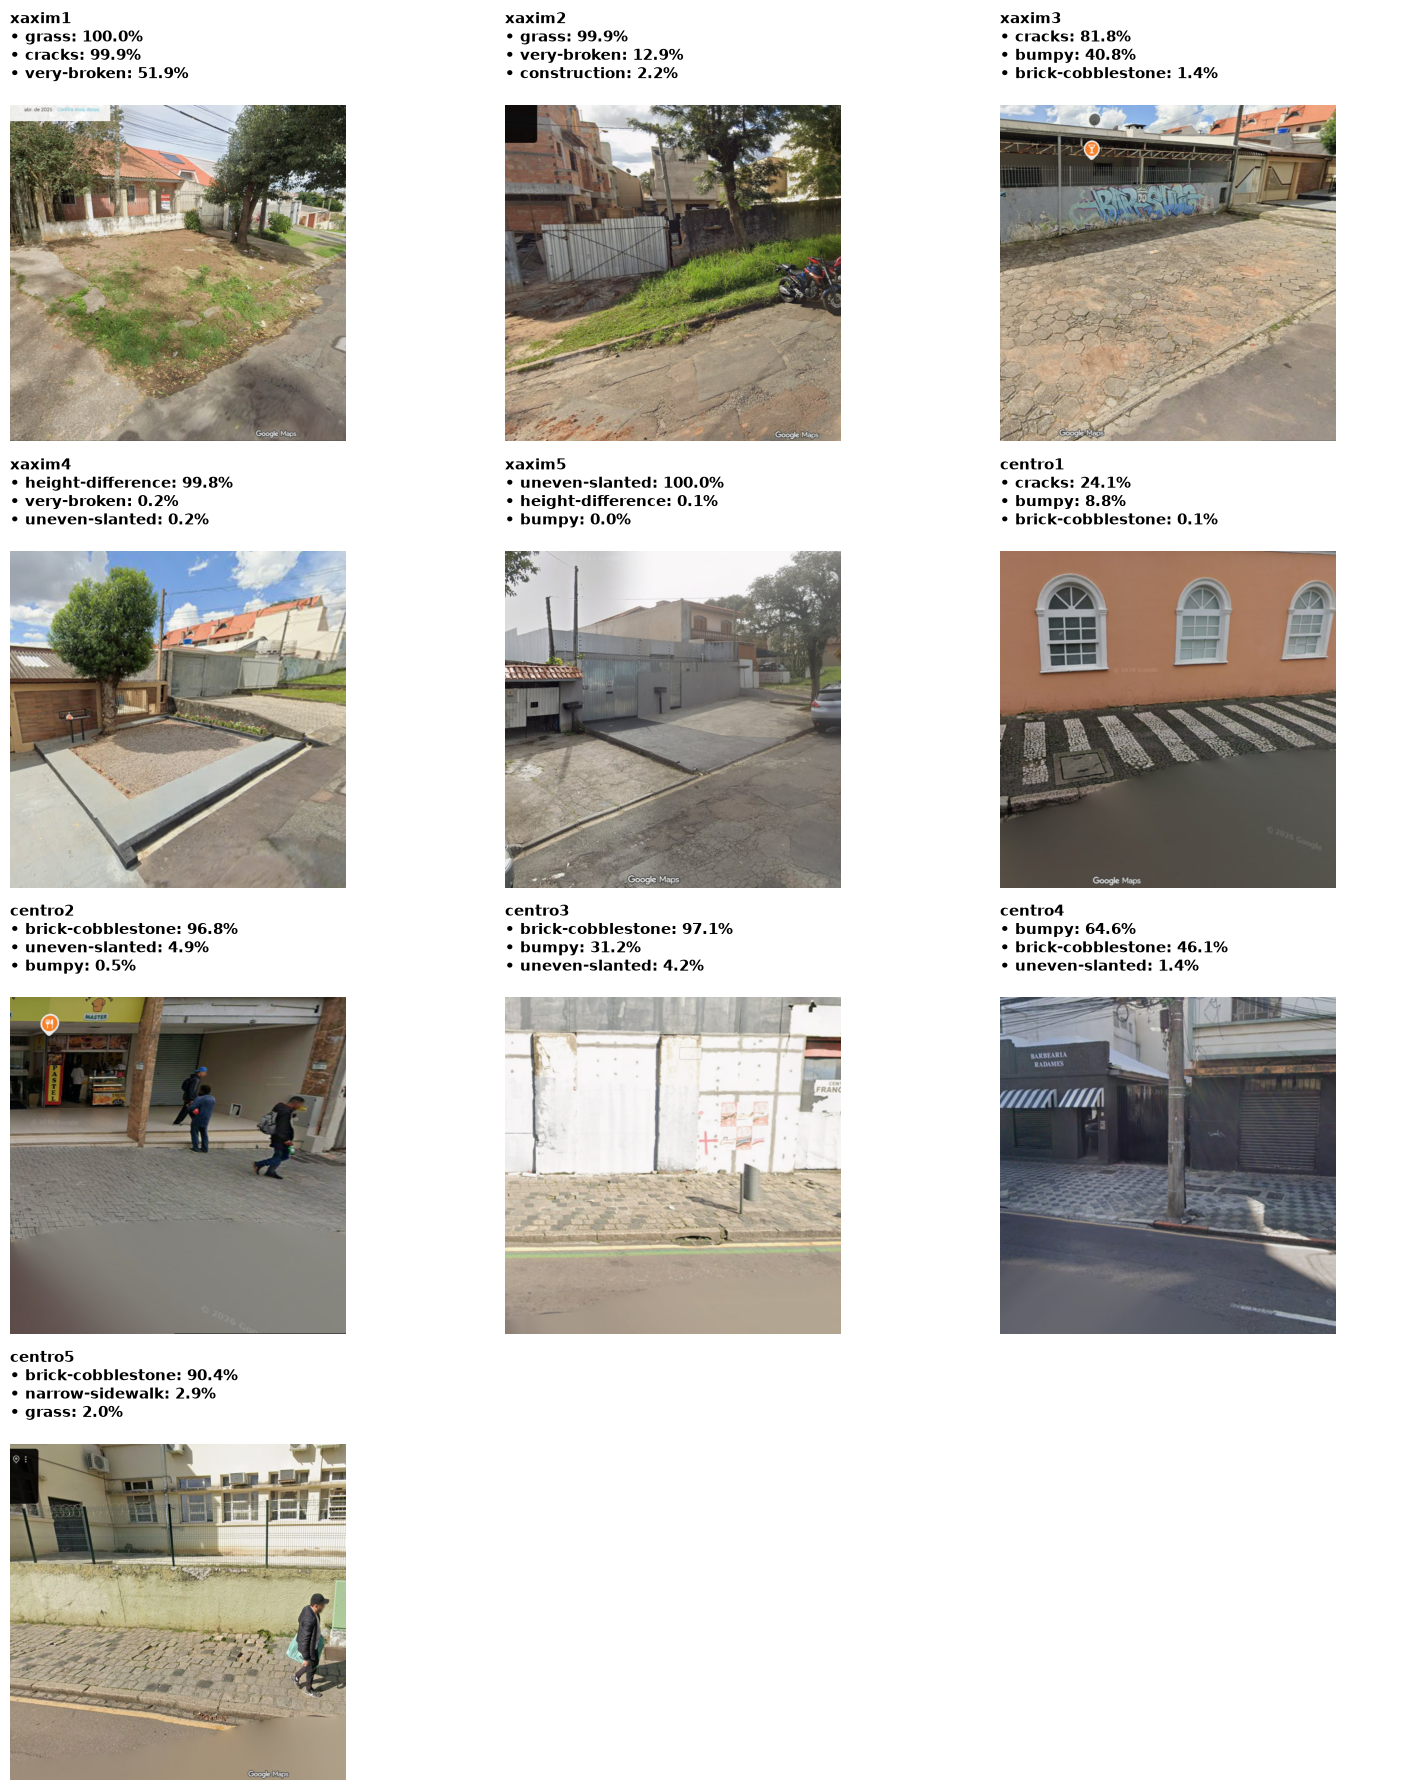

In [10]:
# ==========================================
# 4. DiagnÃ³stico Visual (Street View)
# ==========================================
CLASS_MAP = [
    "brick-cobblestone",
    "bumpy",
    "construction",
    "cracks",
    "grass",
    "height-difference",
    "narrow-sidewalk",
    "rail-tram-track",
    "sand-gravel",
    "uncovered-manhole",
    "uneven-slanted",
    "utility-panel",
    "very-broken"
]

if len(resultados) == 0:
    print("Nenhum resultado para exibir.")
else:
    print("Exibindo imagens e as top 3 classes detectadas:")
    
    num_plots = len(resultados)
    cols = 3
    rows = (num_plots + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4.5 * rows))
    axes = np.atleast_1d(axes).flatten()
        
    for ax, res in zip(axes, resultados[:num_plots]):
        img_id = res['image_id']
        img_path = f"../data/raw/amostras/{img_id}.png"
        if not os.path.exists(img_path):
            img_path = f"../data/raw/amostras/{img_id}.jpg"
            
        if os.path.exists(img_path):
            img = Image.open(img_path)
            ax.imshow(img)
        else:
            ax.imshow(np.full((224, 224, 3), 200, dtype=np.uint8))
            
        ignored_keys = {'image_id', 'bairro', 'label_real'}
        scores = {}
        for k, v in res.items():
            if k in ignored_keys:
                continue
            if k.startswith('Class_'):
                try:
                    idx = int(k.split('_')[1])
                    class_name = CLASS_MAP[idx] if idx < len(CLASS_MAP) else k
                except (ValueError, IndexError):
                    class_name = k
                scores[class_name] = v
            else:
                scores[k] = v
                
        top3 = sorted(scores.items(), key=lambda item: item[1], reverse=True)[:3]
        
        title = f"{img_id}\n"
        for class_name, score in top3:
            title += f"• {class_name}: {score * 100:.1f}%\n"
            
        ax.set_title(title, fontsize=11, fontweight='bold', loc='left')
        ax.axis('off')
        
    for i in range(num_plots, len(axes)):
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()

---
# Parte II: Teste de Generalização com Amostras do Mapillary

Nesta seção, aplicamos o modelo em imagens obtidas diretamente da plataforma **Mapillary** (câmeras veiculares / dashcam de voluntários em Curitiba).
O objetivo é avaliar o comportamento do modelo em um domínio com diferentes ângulos, iluminação e artefatos (como reflexo do para-brisa), mantendo o comparativo entre **Centro** e **Xaxim**.

## 5. Carregamento dos Metadados do Mapillary

Carregamos o arquivo `amostras_mapillary_metadata.csv` que cataloga as 10 imagens capturadas do Mapillary.

In [11]:
# ==========================================
# 5. Carregamento dos Metadados Mapillary
# ==========================================
metadata_mapillary_path = '../data/raw/amostras_mapillary_metadata.csv'

if not os.path.exists(metadata_mapillary_path):
    print(f"ERRO: Arquivo {metadata_mapillary_path} não encontrado!")
else:
    df_mapillary = pd.read_csv(metadata_mapillary_path)
    print(f"Total de amostras Mapillary carregadas: {len(df_mapillary)}")
    display(df_mapillary)

Total de amostras Mapillary carregadas: 10


,image_id,bairro,label_real_binario
0,mapillary_centro1,Centro,Regular
1,mapillary_centro2,Centro,Regular
2,mapillary_centro3,Centro,Regular
3,mapillary_centro4,Centro,Regular
4,mapillary_centro5,Centro,Regular
5,mapillary_xaxim1,Xaxim,Irregular
6,mapillary_xaxim2,Xaxim,Irregular
7,mapillary_xaxim3,Xaxim,Irregular
8,mapillary_xaxim4,Xaxim,Irregular
9,mapillary_xaxim5,Xaxim,Irregular


## 6. Inferência nas Amostras do Mapillary

Processamento das imagens brutas do Mapillary com o extrator DINOv2 e classificação das 13 tags de `SurfaceProblem`.

In [7]:
# ==========================================
# 6. Inferência com DINOv2 (Mapillary)
# ==========================================
pasta_mapillary = '../data/raw/amostras_mapillary'
resultados_mapillary = []

if model is not None and os.path.exists(metadata_mapillary_path):
    for idx, row in df_mapillary.iterrows():
        img_id = row['image_id']
        img_path = os.path.join(pasta_mapillary, f"{img_id}.png")
        
        # Fallback para .jpg caso necessário
        if not os.path.exists(img_path):
            img_path = os.path.join(pasta_mapillary, f"{img_id}.jpg")
            
        try:
            img = Image.open(img_path).convert('RGB')
            img_tensor = transform(img).unsqueeze(0).to(DEVICE)
            
            with torch.no_grad():
                outputs = model(img_tensor)
                probs = torch.sigmoid(outputs).squeeze().cpu().numpy()
            
            res_dict = {
                'image_id': img_id,
                'bairro': row.get('bairro', ''),
                'label_real': row.get('label_real_binario', '')
            }
            
            for i, p in enumerate(probs):
                col_name = CLASS_MAP[i] if i < len(CLASS_MAP) else f'Class_{i}'
                res_dict[col_name] = p
                
            resultados_mapillary.append(res_dict)
            
        except Exception as e:
            print(f"Erro processando imagem {img_path}: {e}")

    df_resultados_mapillary = pd.DataFrame(resultados_mapillary)
    print(f"Inferência concluída para {len(df_resultados_mapillary)} imagens do Mapillary.")
    display(df_resultados_mapillary)
else:
    print("A inferência foi pulada pois o modelo não está carregado ou os metadados não existem.")

Inferência concluída para 10 imagens do Mapillary.


,image_id,bairro,label_real,brick-cobblestone,bumpy,construction,cracks,grass,height-difference,narrow-sidewalk,rail-tram-track,sand-gravel,uncovered-manhole,uneven-slanted,utility-panel,very-broken
0,mapillary_centro1,Centro,Regular,0.001923,0.184150,0.006188,0.001561,0.019924,0.006790,0.000626,0.002922,0.000003,0.000089,0.000005,0.000098,0.012813
1,mapillary_centro2,Centro,Regular,0.000096,0.988587,0.013714,0.000709,0.000213,0.000668,0.000155,0.000433,0.000004,0.000041,0.045701,0.000139,0.000580
2,mapillary_centro3,Centro,Regular,0.014210,0.018695,0.008262,0.000640,0.016484,0.000959,0.000814,0.011763,0.000018,0.000291,0.000044,0.000680,0.039836
3,mapillary_centro4,Centro,Regular,0.007212,0.019405,0.006667,0.002716,0.005961,0.012846,0.003289,0.005425,0.000061,0.000193,0.000174,0.000483,0.249096
4,mapillary_centro5,Centro,Regular,0.000915,0.049926,0.004774,0.074518,0.001839,0.293051,0.002379,0.004457,0.000212,0.002504,0.000597,0.001966,0.023583
5,mapillary_xaxim1,Xaxim,Irregular,0.000150,0.000217,0.002774,0.004389,0.228327,0.000132,0.000175,0.001537,0.000005,0.000033,0.000072,0.000027,0.041773
6,mapillary_xaxim2,Xaxim,Irregular,0.000588,0.089967,0.014575,0.036337,0.690950,0.000956,0.006795,0.002160,0.000078,0.000128,0.000119,0.000164,0.492627
7,mapillary_xaxim3,Xaxim,Irregular,0.000800,0.002254,0.003246,0.003647,0.957230,0.001099,0.003729,0.000807,0.000085,0.000022,0.000193,0.000049,0.791427
8,mapillary_xaxim4,Xaxim,Irregular,0.000042,0.003505,0.000431,0.442317,0.127620,0.000012,0.003737,0.000071,0.000005,0.000003,0.000233,0.000023,0.114458
9,mapillary_xaxim5,Xaxim,Irregular,0.000171,0.000332,0.001409,0.273687,0.128646,0.000253,0.021276,0.000110,0.000018,0.000010,0.009463,0.000028,0.072308


## 7. Diagnóstico Visual das Amostras Mapillary

Visualização lado a lado das 10 amostras do Mapillary com as 3 tags mais prováveis detectadas pelo modelo.
Permite diagnosticar visualmente se a qualidade inferior e a falta de precisão na calçada afeta os resultados.

Exibindo amostras do Mapillary e as top 3 classes preditas:


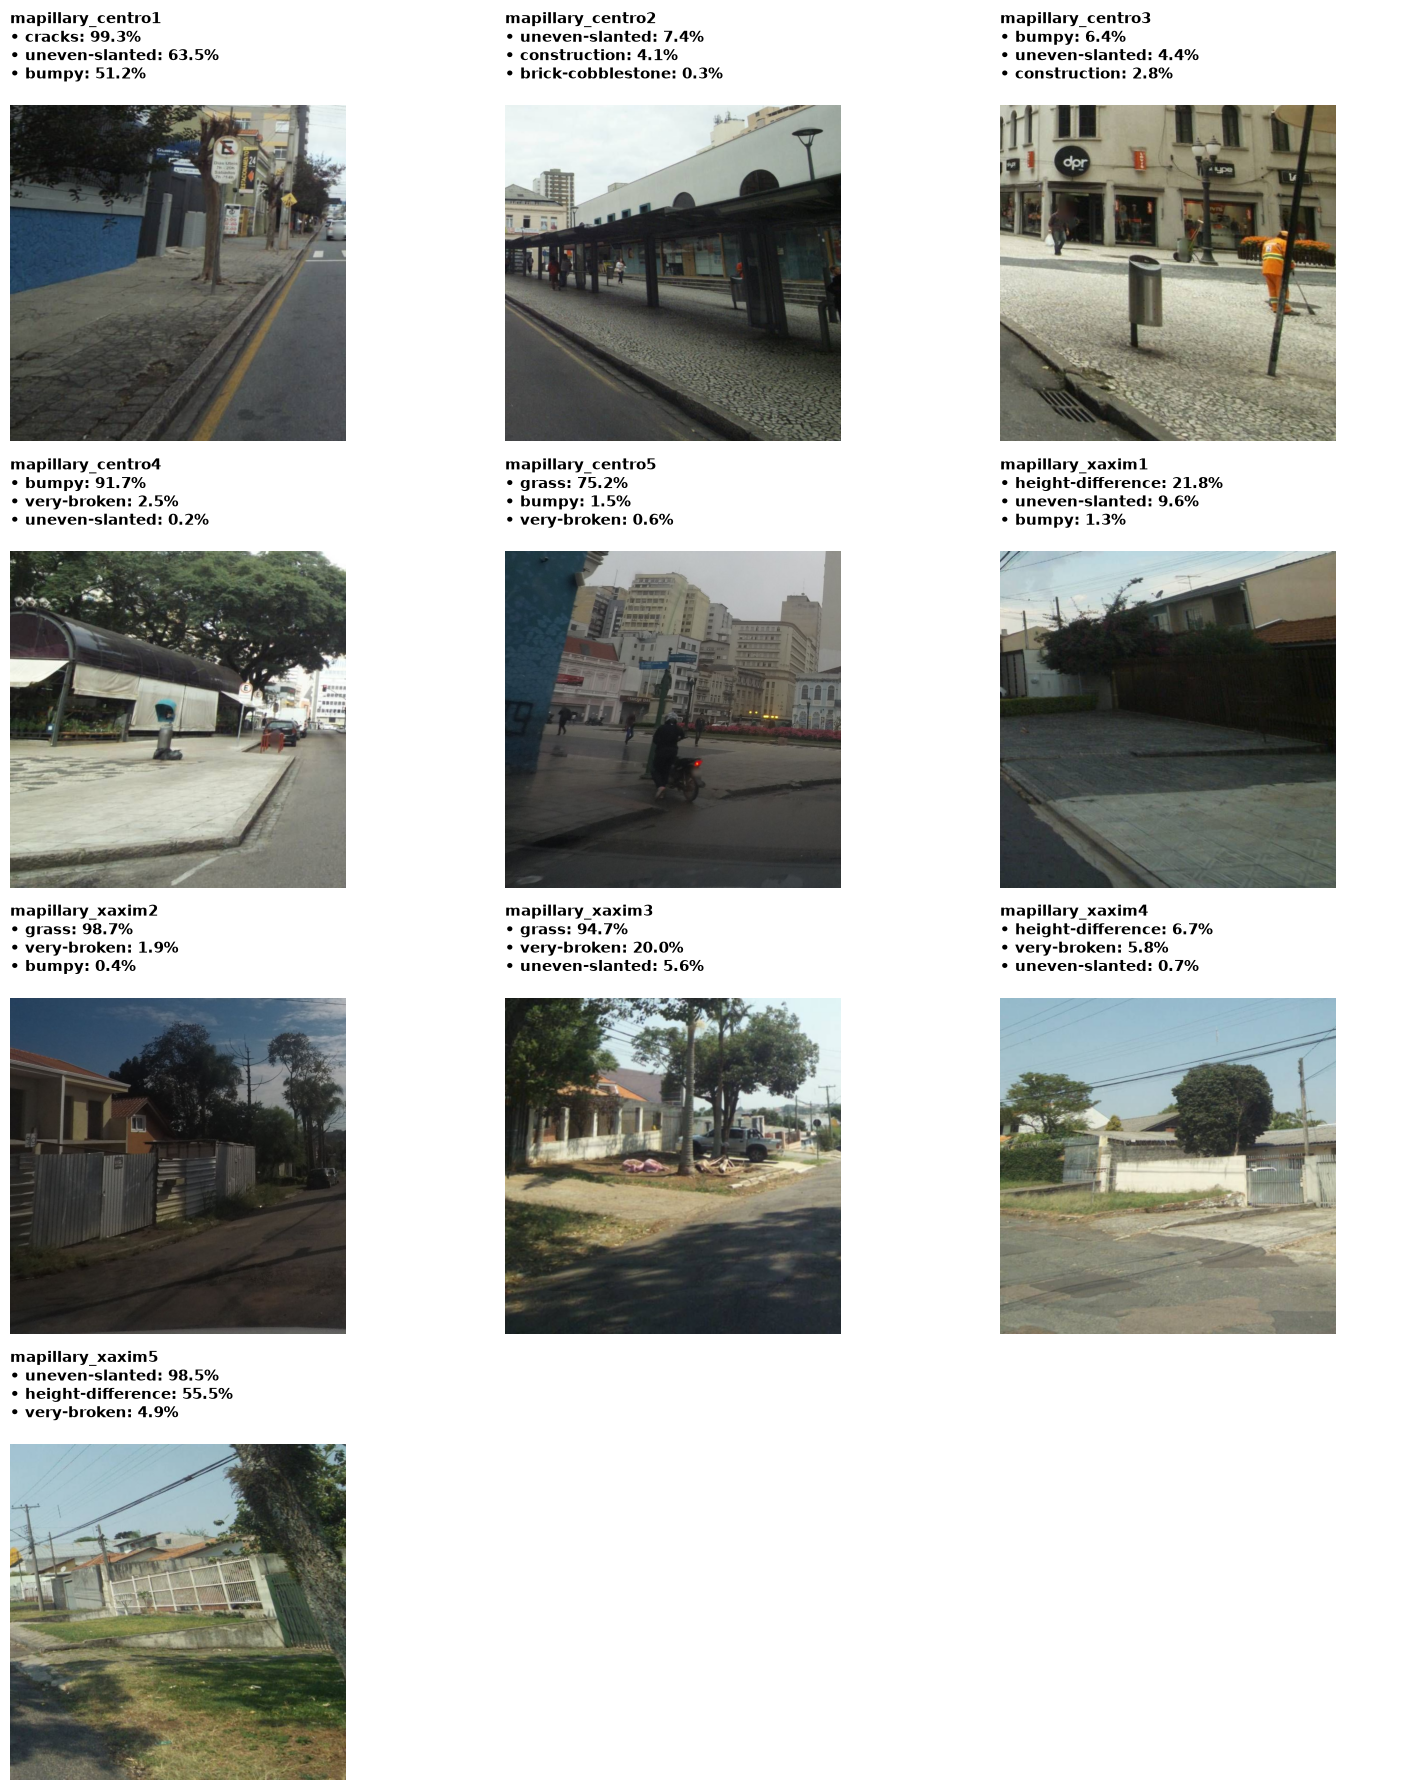

In [12]:
# ==========================================
# 7. DiagnÃ³stico Visual (Mapillary)
# ==========================================
if len(resultados_mapillary) == 0:
    print("Nenhum resultado de Mapillary para exibir.")
else:
    print("Exibindo amostras do Mapillary e as top 3 classes preditas:")
    
    num_plots = len(resultados_mapillary)
    cols = 3
    rows = (num_plots + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4.5 * rows))
    axes = np.atleast_1d(axes).flatten()
        
    for ax, res in zip(axes, resultados_mapillary[:num_plots]):
        img_id = res['image_id']
        img_path = os.path.join(pasta_mapillary, f"{img_id}.png")
        if not os.path.exists(img_path):
            img_path = os.path.join(pasta_mapillary, f"{img_id}.jpg")
            
        if os.path.exists(img_path):
            img = Image.open(img_path)
            ax.imshow(img)
        else:
            ax.imshow(np.full((224, 224, 3), 200, dtype=np.uint8))
            
        ignored_keys = {'image_id', 'bairro', 'label_real'}
        scores = {k: v for k, v in res.items() if k not in ignored_keys}
                
        top3 = sorted(scores.items(), key=lambda item: item[1], reverse=True)[:3]
        
        title = f"{img_id}\n"
        for class_name, score in top3:
            title += f"• {class_name}: {score * 100:.1f}%\n"
            
        ax.set_title(title, fontsize=11, fontweight='bold', loc='left')
        ax.axis('off')
        
    for i in range(num_plots, len(axes)):
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()